# Предобработка и предварительный EDA


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка готового датасета


In [22]:
df_raw = pd.read_csv('data/olist_enriched.csv')
df_raw

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,seller_id,product_id,...,delivery_date,purchase_precipitation_mm,purchase_temp_avg_c,purchase_heavy_rain,delivery_precipitation_mm,delivery_temp_avg_c,delivery_heavy_rain,purchase_is_holiday,delivery_is_holiday,days_to_next_holiday
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,...,2017-10-10,5.0,20.3,0,2.4,25.3,0.0,0,0,396
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,...,2018-08-07,2.5,23.9,0,1.2,24.8,0.0,0,0,101
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,...,2018-08-17,0.8,25.2,0,2.8,22.5,0.0,0,0,86
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-12-02,1.4,26.4,0,2.2,26.4,0.0,0,0,349
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-16,3.2,19.0,0,0.9,20.0,0.0,0,0,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,e24fc9fcd865784fb25705606fe3dfe7,ac35486adb7b02598c182c2ff2e05254,...,2017-03-17,2.3,23.6,0,10.4,23.6,0.0,0,0,603
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1f9ab4708f3056ede07124aad39a2554,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,2018-02-28,2.3,20.0,0,0.1,23.0,0.0,0,0,269
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,d50d79cb34e38265a8649c383dcffd48,b80910977a37536adeddd63663f916ad,...,2017-09-21,2.3,23.1,0,4.3,23.9,0.0,0,0,432
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,a1043bafd471dff536d0c462352beb48,d1c427060a0f73f6b889a5c7c61f2ac4,...,2018-01-25,76.1,24.1,1,3.3,28.3,0.0,0,0,298


In [23]:
df_raw.dtypes

order_id                     object
customer_id                  object
order_status                 object
order_purchase_timestamp     object
order_approved_at            object
                             ...   
delivery_temp_avg_c         float64
delivery_heavy_rain         float64
purchase_is_holiday           int64
delivery_is_holiday           int64
days_to_next_holiday          int64
Length: 68, dtype: object

In [24]:
df = df_raw.copy()
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

df['order_purchase_timestamp'].min(), df['order_purchase_timestamp'].max()

(Timestamp('2016-09-15 12:16:38'), Timestamp('2018-08-29 15:00:37'))

## Проверка качества данных


### Дубли и целостность


In [25]:
exact_duplicates = df.duplicated().sum()
duplicated_order_ids = df['order_id'].duplicated().sum()

print(f'Полных дублей: {exact_duplicates}')
print(f'Повторяющихся order_id: {duplicated_order_ids}')

Полных дублей: 0
Повторяющихся order_id: 0


### Проверка таргетов


In [26]:
print('Некорректных значений is_delayed:', (~df['is_delayed'].isin([0, 1])).sum())
print('Метки is_delayed без известного delay_days:', df['delay_days'].isna().sum())
print('Метки, не совпадающие со знаком delay_days:', (df['delay_days'].notna() & (df['is_delayed'] != (df['delay_days'] > 0).astype(int))).sum())
print('Некорректных значений total_freight:', (df['total_freight'].isna() | (df['total_freight'] < 0)).sum())

Некорректных значений is_delayed: 0
Метки is_delayed без известного delay_days: 8
Метки, не совпадающие со знаком delay_days: 0
Некорректных значений total_freight: 0


In [27]:
df = df.loc[~df['delay_days'].isna()].copy()

### Пропуски


In [28]:
missing = (df.isna().agg(['sum', 'mean']).T.rename(columns={'sum': 'missing_n', 'mean': 'missing_share'}))
missing['missing_pct'] = missing['missing_share'] * 100
missing = missing.query('missing_n > 0').sort_values('missing_pct', ascending=False)

missing[['missing_n', 'missing_pct']]


,missing_n,missing_pct
product_category_name_english,1378.0,1.428423
product_photos_qty,1359.0,1.408728
review_score,646.0,0.669638
distance_km,478.0,0.495491
customer_lat,264.0,0.273660
customer_lng,264.0,0.273660
seller_lat,215.0,0.222867
seller_lng,215.0,0.222867
product_weight_g,16.0,0.016585
product_width_cm,16.0,0.016585


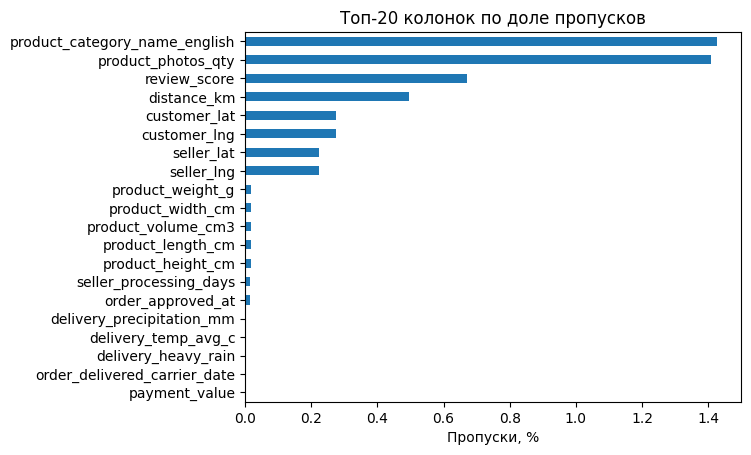

In [29]:
ax = missing['missing_pct'].head(20).sort_values().plot(kind='barh', title='Топ-20 колонок по доле пропусков')
ax.set_xlabel('Пропуски, %')

plt.show()

In [30]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_columns = [c for c in categorical_columns if c not in ['order_id']]

df[categorical_columns] = df[categorical_columns].fillna('Unknown')

### Невозможные значения и выбросы


In [31]:
cols = ['n_items', 'total_price', 'total_freight', 'avg_price', 'payment_installments', 'payment_value',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_photos_qty', 'product_volume_cm3',
    'distance_km', 'customer_population', 'customer_population_density', 'estimated_delivery_days']


Значения меньше нуля

In [32]:
(df[cols] < 0).sum()[lambda x: x > 0]

Series([], dtype: int64)

Нулевые значения

In [33]:
(df[cols] == 0).sum()[lambda x: x > 0]

total_freight           336
payment_installments      2
product_weight_g          6
distance_km              23
dtype: int64

Пропуски

In [34]:
df[cols].isna().sum()[lambda x: x > 0]

payment_installments       1
payment_value              1
product_weight_g          16
product_length_cm         16
product_height_cm         16
product_width_cm          16
product_photos_qty      1359
product_volume_cm3        16
distance_km              478
dtype: int64

In [35]:
cols = ['total_price', 'total_freight', 'product_weight_g', 'product_volume_cm3', 'distance_km', 'estimated_delivery_days']

rows = []
for col in cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    rows.append({'column': col, 'outliers_n': mask.sum(), 'outliers_pct': round(mask.mean() * 100, 2)})

pd.DataFrame(rows).set_index('column')

,outliers_n,outliers_pct
column,,
total_price,7658,7.94
total_freight,9694,10.05
product_weight_g,13702,14.21
product_volume_cm3,8562,8.88
distance_km,7418,7.73
estimated_delivery_days,2317,2.40


## EDA


### Распределения таргетных переменных


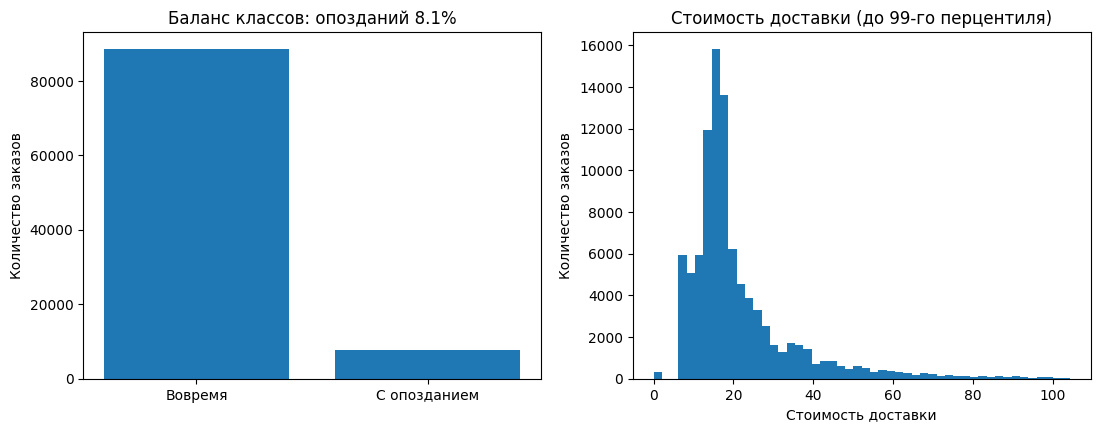

In [36]:
delay_counts = df['is_delayed'].value_counts().sort_index()
delay_rate = df['is_delayed'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(['Вовремя', 'С опозданием'], delay_counts.reindex([0, 1]).values)
axes[0].set_title(f'Баланс классов: опозданий {delay_rate * 100:.1f}%')
axes[0].set_ylabel('Количество заказов')

freight_cap = df['total_freight'].quantile(0.99)
axes[1].hist(df.loc[df['total_freight'] <= freight_cap, 'total_freight'], bins=50)
axes[1].set_title('Стоимость доставки (до 99-го перцентиля)')
axes[1].set_xlabel('Стоимость доставки')
axes[1].set_ylabel('Количество заказов')

plt.show()


### Динамика числа заказов

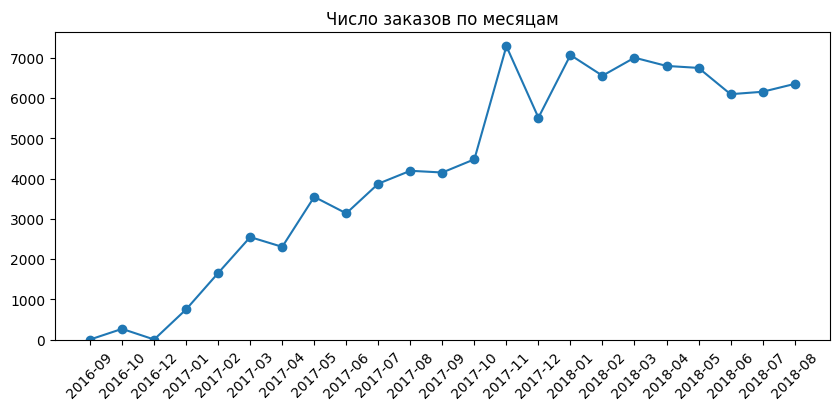

In [37]:
monthly = df.groupby('purchase_month')['order_id'].count()

plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.xticks(rotation=45)
plt.ylim(0)
plt.title('Число заказов по месяцам')

plt.show()

In [38]:
before_filter = len(df)

df = df[df['order_purchase_timestamp'] >= '2017-01-01'].copy()
removed = before_filter - len(df)

print(f'Удалено строк: {removed} ({removed/before_filter*100:.2f}% от датасета)')
print(f'Осталось: {len(df)} заказов')

Удалено строк: 267 (0.28% от датасета)
Осталось: 96203 заказов


In [39]:
df = df.sort_values('order_purchase_timestamp').reset_index(drop=True)
df.to_csv('data/olist_enriched_clean.csv', index=False)